# **Домашнее задание к семинару 12 (HW12)**

**Тема:** временные ряды, корректная валидация по времени, лаговые признаки и базовый прогноз с GRU.

**Цель:**

Закрепить:
- отличие временных рядов от обычных табличных данных с точки зрения валидации;
- практику корректного temporal split вместо случайного random split;
- построение лаговых, rolling- и календарных признаков;
- сравнение простых baseline-подходов с рекуррентной моделью;
- аккуратное оформление результата: один ноутбук, короткий отчёт, артефакты эксперимента.

### **1. Импорты, seed и устройство**

#### 1.1. Импортировать библиотеки: torch, torchvision, numpy, matplotlib (и всё, что нужно по делу).

In [63]:
# Импорты
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

#### 1.2. Зафиксировать seed (минимум torch.manual_seed, желательно также numpy).

In [2]:
# Seed
SEED = 666

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#### 1.3.  Определить устройство (cuda при наличии, иначе cpu) и убедиться, что и модель, и батчи переводятся на один device.

In [3]:
# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

Устройство: cpu


### **2. Данные и первичный анализ**

#### 2.1. Импорт данных

In [ ]:
# путь к локальному датасету
DATA_PATH = "data/S12-hw-dataset.csv"
df = pd.read_csv(DATA_PATH)
df

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
...,...,...
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53


In [12]:
# приведение даты к datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
...,...,...
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53


In [13]:
# базовый анализ
print("Shape:", df.shape)
print("Date range:", df['date'].min(), "-", df['date'].max())
print("Missing values:\n", df.isna().sum())

Shape: (4320, 2)
Date range: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Missing values:
 date      0
target    0
dtype: int64


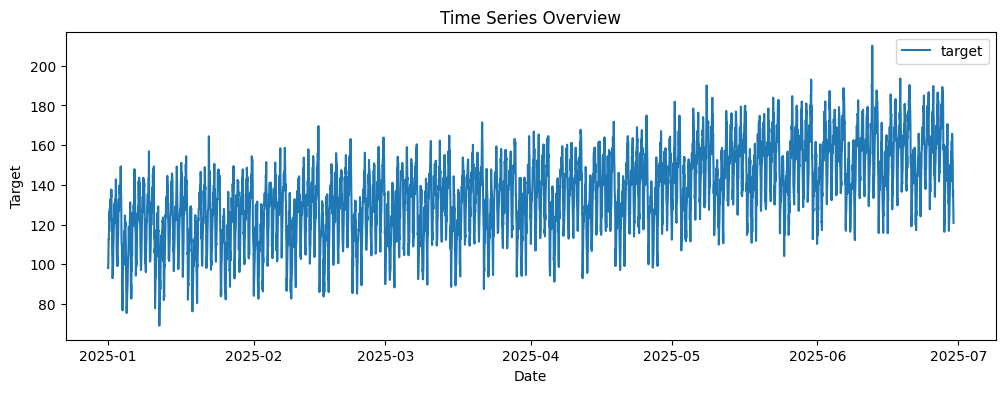

In [14]:
# базовый график ряда
plt.figure(figsize=(12,4))
plt.plot(df['date'], df['target'], label='target')
plt.xlabel("Date")
plt.ylabel("Target")
plt.title("Time Series Overview")
plt.legend()
plt.show()

#### 2.2. Корректный temporal split

In [15]:
# доли для split
train_size = 0.7
val_size = 0.15
test_size = 0.15

n = len(df)
train_end = int(n*train_size)
val_end = train_end + int(n*val_size)

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print(f"Train: 0-{train_end}, Validation: {train_end}-{val_end}, Test: {val_end}-{n}")

Train: 0-3024, Validation: 3024-3672, Test: 3672-4320


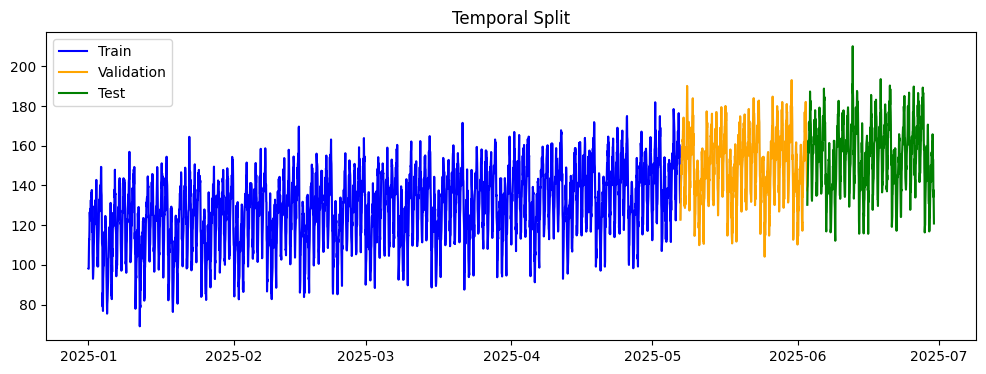

In [16]:
# визуализация
plt.figure(figsize=(12,4))
plt.plot(df['date'], df['target'], color='lightgray')
plt.plot(train['date'], train['target'], label='Train', color='blue')
plt.plot(val['date'], val['target'], label='Validation', color='orange')
plt.plot(test['date'], test['target'], label='Test', color='green')
plt.title("Temporal Split")
plt.legend()
plt.show()

#### 2.3. Признаки для baseline-моделей

In [17]:
def create_features(df):
    df_feat = df.copy()
    # лаги
    df_feat['lag_1'] = df_feat['target'].shift(1)
    df_feat['lag_7'] = df_feat['target'].shift(7)
    df_feat['lag_14'] = df_feat['target'].shift(14)
    # rolling
    df_feat['rolling_mean_7'] = df_feat['target'].shift(1).rolling(7).mean()
    df_feat['rolling_std_7'] = df_feat['target'].shift(1).rolling(7).std()
    # календарные признаки
    df_feat['day_of_week'] = df_feat['date'].dt.dayofweek
    return df_feat

train_feat = create_features(train)
val_feat = create_features(val)
test_feat = create_features(test)

#### 2.4. Оконное представление для GRU

In [18]:
WINDOW_SIZE = 14

class TimeSeriesDataset(Dataset):
    def __init__(self, series, window_size):
        self.series = series
        self.window_size = window_size

    def __len__(self):
        return len(self.series) - self.window_size

    def __getitem__(self, idx):
        x = self.series[idx:idx+self.window_size]
        y = self.series[idx+self.window_size]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# масштабирование
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train['target'].values.reshape(-1,1)).flatten()
val_scaled = scaler.transform(val['target'].values.reshape(-1,1)).flatten()
test_scaled = scaler.transform(test['target'].values.reshape(-1,1)).flatten()

train_ds = TimeSeriesDataset(train_scaled, WINDOW_SIZE)
val_ds = TimeSeriesDataset(val_scaled, WINDOW_SIZE)
test_ds = TimeSeriesDataset(test_scaled, WINDOW_SIZE)

BATCH_SIZE = 32
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

### 2.5. Базовые функции обучения и оценки

In [22]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

def train_model(model, train_dl, val_dl, epochs=20, lr=1e-3):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val_mae = float('inf')
    history = {'train_loss':[], 'val_loss':[], 'val_mae':[]}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for x,y in train_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            y_pred = model(x)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # валидация
        model.eval()
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for x,y in val_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                y_pred = model(x)
                val_preds.append(y_pred.cpu().numpy())
                val_targets.append(y.cpu().numpy())
        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)
        val_mae = mean_absolute_error(val_targets, val_preds)
        val_rmse = mean_squared_error(val_targets, val_preds, squared=False)

        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(val_rmse)
        history['val_mae'].append(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            torch.save(model.state_dict(), "artifacts/best_gru.pt")

    return history

### **3. Эксперименты**

In [30]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero = y_true != 0
    return np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred))
    non_zero = denominator != 0
    return 2*np.mean(np.abs(y_pred[non_zero]-y_true[non_zero])/denominator[non_zero])*100

#### 3.1. B1 (naive-last)

In [33]:
y_val_pred_B1 = val['target'].shift(1).fillna(method='bfill').values
y_test_pred_B1 = test['target'].shift(1).fillna(method='bfill').values

runs = []

runs.append({
    "experiment_id": "B1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": f"train: {len(train)}, val: {len(val)}, test: {len(test)}",
    "window_size": "",
    "horizon": 1,
    "model_summary": "naive-last",
    "features_summary": "target lag 1",
    "scaler": "",
    "optimizer": "",
    "lr": "",
    "epochs_trained": "",
    "best_val_mae": mean_absolute_error(val['target'], y_val_pred_B1),
    "best_val_rmse": np.sqrt(mean_squared_error(val['target'], y_val_pred_B1)),
    "best_val_mape": mape(val['target'], y_val_pred_B1),
    "test_mae": mean_absolute_error(test['target'], y_test_pred_B1),
    "test_rmse": np.sqrt(mean_squared_error(test['target'], y_test_pred_B1)),
    "test_mape": mape(test['target'], y_test_pred_B1),
    "notes": ""
})

/tmp/ipykernel_9139/3093964387.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_val_pred_B1 = val['target'].shift(1).fillna(method='bfill').values
/tmp/ipykernel_9139/3093964387.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_test_pred_B1 = test['target'].shift(1).fillna(method='bfill').values


#### 3.2. B2 (moving-average)

In [34]:
WINDOW_MA = 7
full_series = pd.concat([train['target'], val['target'], test['target']])
y_val_pred_B2 = full_series.rolling(WINDOW_MA).mean().iloc[len(train):len(train)+len(val)].values
y_test_pred_B2 = full_series.rolling(WINDOW_MA).mean().iloc[len(train)+len(val):].values

runs.append({
    "experiment_id": "B2",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": f"train: {len(train)}, val: {len(val)}, test: {len(test)}",
    "window_size": WINDOW_MA,
    "horizon": 1,
    "model_summary": f"moving-average({WINDOW_MA})",
    "features_summary": "target rolling mean",
    "scaler": "",
    "optimizer": "",
    "lr": "",
    "epochs_trained": "",
    "best_val_mae": mean_absolute_error(val['target'], y_val_pred_B2),
    "best_val_rmse": np.sqrt(mean_squared_error(val['target'], y_val_pred_B2)),
    "best_val_mape": mape(val['target'], y_val_pred_B2),
    "test_mae": mean_absolute_error(test['target'], y_test_pred_B2),
    "test_rmse": np.sqrt(mean_squared_error(test['target'], y_test_pred_B2)),
    "test_mape": mape(test['target'], y_test_pred_B2),
    "notes": ""
})

#### 3.3. B3 (ridge-lag-features)

In [35]:
FEATURES = ['lag_1','lag_7','lag_14','rolling_mean_7','rolling_std_7','day_of_week']
X_train_B3 = train_feat[FEATURES].fillna(0)
X_val_B3 = val_feat[FEATURES].fillna(0)
X_test_B3 = test_feat[FEATURES].fillna(0)

scaler_B3 = StandardScaler()
X_train_scaled = scaler_B3.fit_transform(X_train_B3)
X_val_scaled = scaler_B3.transform(X_val_B3)
X_test_scaled = scaler_B3.transform(X_test_B3)

ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_scaled, train_feat['target'])

y_val_pred_B3 = ridge.predict(X_val_scaled)
y_test_pred_B3 = ridge.predict(X_test_scaled)

runs.append({
    "experiment_id": "B3",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": f"train: {len(train)}, val: {len(val)}, test: {len(test)}",
    "window_size": "",
    "horizon": 1,
    "model_summary": "Ridge(alpha=1.0)",
    "features_summary": ", ".join(FEATURES),
    "scaler": "StandardScaler",
    "optimizer": "",
    "lr": "",
    "epochs_trained": "",
    "best_val_mae": mean_absolute_error(val_feat['target'], y_val_pred_B3),
    "best_val_rmse": np.sqrt(mean_squared_error(val_feat['target'], y_val_pred_B3)),
    "best_val_mape": mape(val_feat['target'], y_val_pred_B3),
    "test_mae": mean_absolute_error(test_feat['target'], y_test_pred_B3),
    "test_rmse": np.sqrt(mean_squared_error(test_feat['target'], y_test_pred_B3)),
    "test_mape": mape(test_feat['target'], y_test_pred_B3),
    "notes": ""
})

#### 3.4. R1 (gru-forecast)

In [ ]:
WINDOW_GRU = WINDOW_SIZE
HIDDEN_SIZE = 32
EPOCHS = 20
LR = 1e-3

gru_model = GRUModel(input_size=1, hidden_size=HIDDEN_SIZE).to(device)

history = train_model(gru_model, train_dl, val_dl, epochs=EPOCHS, lr=LR)

gru_model.load_state_dict(torch.load(os.path.join('artifacts', 'best_gru.pt')))
gru_model.eval()

def predict_series(model, dataset):
    preds = []
    with torch.no_grad():
        for x, _ in dataset:
            x = x.unsqueeze(0).to(device)
            y_pred = model(x)
            preds.append(y_pred.item())
    return np.array(preds)

y_val_pred_R1 = predict_series(gru_model, val_ds)
y_test_pred_R1 = predict_series(gru_model, test_ds)

runs.append({
    "experiment_id": "R1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": f"train: {len(train)}, val: {len(val)}, test: {len(test)}",
    "window_size": WINDOW_GRU,
    "horizon": 1,
    "model_summary": f"GRU(hidden_size={HIDDEN_SIZE})",
    "features_summary": "windowed series",
    "scaler": "StandardScaler",
    "optimizer": "Adam",
    "lr": LR,
    "epochs_trained": EPOCHS,
    "best_val_mae": mean_absolute_error(val_scaled[WINDOW_GRU:], y_val_pred_R1),
    "best_val_rmse": np.sqrt(mean_squared_error(val_scaled[WINDOW_GRU:], y_val_pred_R1)),
    "best_val_mape": mape(val_scaled[WINDOW_GRU:], y_val_pred_R1),
    "test_mae": mean_absolute_error(test_scaled[WINDOW_GRU:], y_test_pred_R1),
    "test_rmse": np.sqrt(mean_squared_error(test_scaled[WINDOW_GRU:], y_test_pred_R1)),
    "test_mape": mape(test_scaled[WINDOW_GRU:], y_test_pred_R1),
    "notes": ""
})

### **4. Артефакты**

In [ ]:
runs_df = pd.DataFrame(runs)
runs_df.to_csv("artifacts/runs.csv", index=False)
runs_df

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,666,"train: 3024, val: 648, test: 648",,1,naive-last,target lag 1,,,,,6.428565,8.190584,4.384684,6.331173,8.053965,4.139900,
1,B2,forecasting,S12-hw-dataset.csv,666,"train: 3024, val: 648, test: 648",7,1,moving-average(7),target rolling mean,,,,,10.085873,12.130331,6.994529,10.099742,12.160304,6.767431,
2,B3,forecasting,S12-hw-dataset.csv,666,"train: 3024, val: 648, test: 648",,1,Ridge(alpha=1.0),"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler,,,,7.489560,9.587755,5.009812,7.665404,9.983533,4.923127,
3,R1,forecasting,S12-hw-dataset.csv,666,"train: 3024, val: 648, test: 648",14,1,GRU(hidden_size=32),windowed series,StandardScaler,Adam,0.001,20,0.323218,0.410671,135.678682,0.374744,0.471929,61.892514,


In [ ]:
gru_config = {
    "architecture": "GRU",
    "input_size": 1,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": 1,
    "window_size": WINDOW_GRU,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LR,
    "optimizer": "Adam",
    "seed": SEED,
    "scaler": "StandardScaler"
}

config_path = "artifacts/best_gru_config.json"
with open(config_path, "w") as f:
    json.dump(gru_config, f, indent=4)

print(f"Конфигурация GRU сохранена")

Конфигурация GRU сохранена


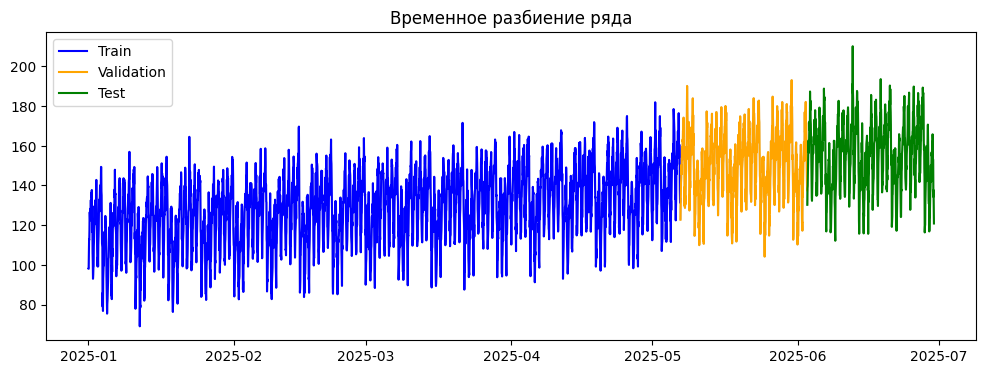

In [ ]:
# series_split.png
plt.figure(figsize=(12,4))
plt.plot(df['date'], df['target'], color='lightgray')
plt.plot(train['date'], train['target'], color='blue', label='Train')
plt.plot(val['date'], val['target'], color='orange', label='Validation')
plt.plot(test['date'], test['target'], color='green', label='Test')
plt.title("Временное разбиение ряда")
plt.legend()
plt.savefig(os.path.join("artifacts/figures", "series_split.png"))
plt.show()

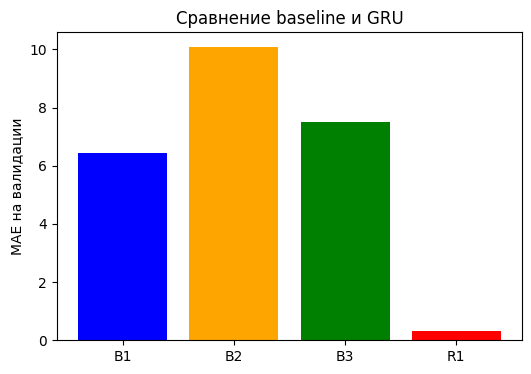

In [ ]:
# baselines_compare.png
val_mae_vals = [runs[0]['best_val_mae'], runs[1]['best_val_mae'], runs[2]['best_val_mae'], runs[3]['best_val_mae']]
plt.figure(figsize=(6,4))
plt.bar(['B1','B2','B3','R1'], val_mae_vals, color=['blue','orange','green','red'])
plt.ylabel("MAE на валидации")
plt.title("Сравнение baseline и GRU")
plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()

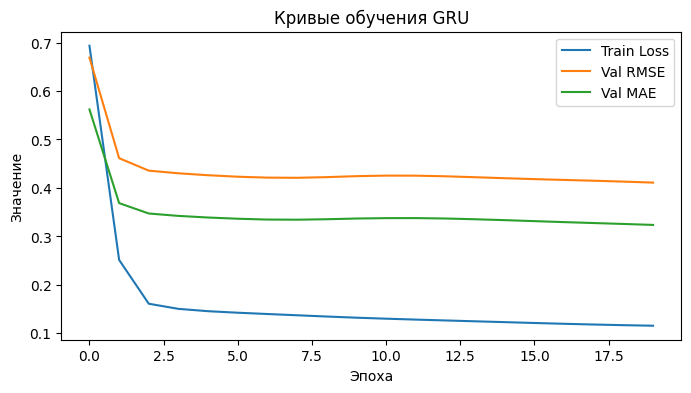

In [ ]:
# gru_learning_curves.png
plt.figure(figsize=(8,4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val RMSE')
plt.plot(history['val_mae'], label='Val MAE')
plt.xlabel("Эпоха")
plt.ylabel("Значение")
plt.title("Кривые обучения GRU")
plt.legend()
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()

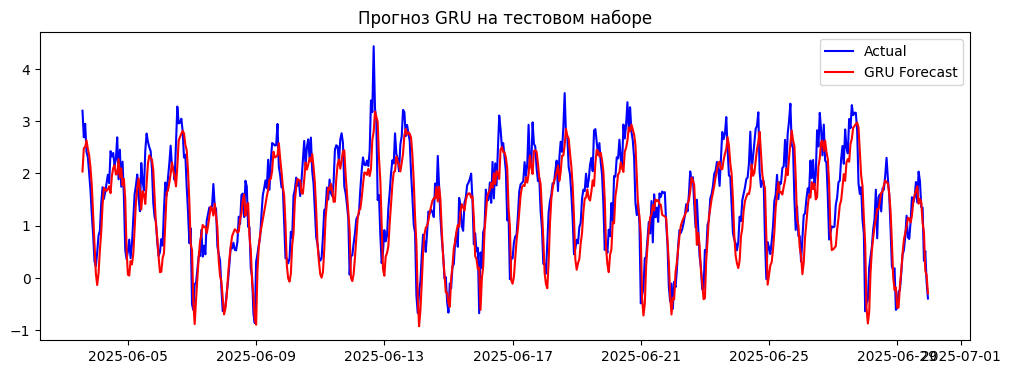

In [ ]:
# best_forecast_test.png
plt.figure(figsize=(12,4))
plt.plot(test['date'][WINDOW_GRU:], test_scaled[WINDOW_GRU:], label='Actual', color='blue')
plt.plot(test['date'][WINDOW_GRU:], y_test_pred_R1, label='GRU Forecast', color='red')
plt.title("Прогноз GRU на тестовом наборе")
plt.legend()
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()